Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [106]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## 2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [107]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [108]:
categorical=movie_metadata.select_dtypes(include=[object]).columns.tolist()
movie_metadata[categorical]=movie_metadata[categorical].astype('category')

## 3 Check for missing variables and correct as needed.

In [109]:
movie_metadata.isna().sum()
#drop rows with missing data
movie_metadata=movie_metadata.dropna()

In [110]:
#drop irrelevant columns
movie_metadata=movie_metadata.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'],axis=1)

In [111]:
#use one hot encoding for other categorical variables
encoder = OneHotEncoder(sparse_output=False)

In [112]:
movie_metadata['imdb_score']=movie_metadata['imdb_score'].astype('float64')

In [113]:
# Categorize imdb_score into two classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 7.5 else "average" if x >= 5.0 else "low"
)

# Check the value counts
#print(movie_metadata["imdb_score"].value_counts())

imdb_encoded=encoder.fit_transform(movie_metadata[["imdb_score"]])
imdb_1h = pd.DataFrame(
    imdb_encoded,
    columns=encoder.get_feature_names_out(['imdb_score']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['imdb_score']), imdb_1h], axis=1)

In [ ]:
## for directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

In [ ]:
## for title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

In [ ]:
## for first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [ ]:
## for country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [ ]:
## for content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [ ]:
## for language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

In [ ]:
## for color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

In [121]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3755 entries, 0 to 5042
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_critic_for_reviews        3755 non-null   float64
 1   duration                      3755 non-null   float64
 2   director_facebook_likes       3755 non-null   float64
 3   actor_3_facebook_likes        3755 non-null   float64
 4   actor_1_facebook_likes        3755 non-null   float64
 5   gross                         3755 non-null   float64
 6   num_voted_users               3755 non-null   int64  
 7   cast_total_facebook_likes     3755 non-null   int64  
 8   facenumber_in_poster          3755 non-null   float64
 9   num_user_for_reviews          3755 non-null   float64
 10  budget                        3755 non-null   float64
 11  actor_2_facebook_likes        3755 non-null   float64
 12  aspect_ratio                  3755 non-null   float64
 13  movie_fa

In [ ]:
collapse = movie_metadata['country_Big Country Producer','country_Other','actor_1_name_Famous','actor_1_name_Other','director_name_Famous','director_name_Other','title_year_middle','title_year_new','title_year_old','imdb_score_average','imdb_score_high','imdb_score_low','content_rating_Other','content_rating_PG-13','content_rating_R','language_English','language_French','language_Other','color_Black and White','color_Color']
movie_metadata['collapse']=movie_metadata[collapse].astype('category')

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [122]:
#calculate the prevalence
print(644/3157)

0.2039911308203991


This number means that the possibility of predicting a movie with a high imdb score is 0.204.

## 6 Split your data into test, tune, and train. (80/10/10)

In [123]:
X= movie_metadata.drop(columns=['imdb_score_high','imdb_score_average'])
y= movie_metadata['imdb_score_high']

In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)

## 7 Create the kfold object for cross validation.

In [125]:
from sklearn.model_selection import RepeatedStratifiedKFold

kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

## 8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter 

In [126]:
scoring = ['roc_auc','recall','balanced_accuracy']

In [127]:
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

## 9 Build the classifier object 

In [128]:
from sklearn.preprocessing import LabelEncoder

# Convert target variable to numerical labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)  # Do the same for test data if applicable

print(le.classes_)  # Check label encoding mapping

[0. 1.]


In [129]:
cl= DecisionTreeClassifier(random_state=1000)

## 10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [130]:
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')

## 11 Fit the model to the training data.

In [131]:
#execute search on our training data, this may take a few seconds ...
model = search.fit(X_train, y_train)

## 12 What is the best depth value?

In [132]:
#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print(best)

DecisionTreeClassifier(max_depth=5, random_state=1000)


The best depth value is 5.

In [133]:
#What about the specific scores (roc_auc, recall, balanced_accuracy)? Let's try and extract them to see what we are working with ...
print(model.cv_results_) #This is a dictionary and in order to extract info we need the keys

{'mean_fit_time': array([0.00642116, 0.00557759, 0.00812013, 0.01110964, 0.01214924,
       0.01480645, 0.01607592, 0.01860103, 0.02141414, 0.02236918,
       0.02400251]), 'std_fit_time': array([0.00744321, 0.00161122, 0.0024024 , 0.00461668, 0.00274028,
       0.00374129, 0.00239561, 0.00281098, 0.00464068, 0.00322764,
       0.00414665]), 'mean_score_time': array([0.00388914, 0.00308745, 0.0035021 , 0.00410999, 0.00388627,
       0.00370625, 0.00395721, 0.00439559, 0.00385199, 0.0036088 ,
       0.00401958]), 'std_score_time': array([0.00264059, 0.00135498, 0.00163824, 0.00317716, 0.00225963,
       0.00171119, 0.00166998, 0.00187555, 0.00207967, 0.00202314,
       0.00269996]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999), 'params': [{'max_depth': 1}, {'max_depth': 2}, {'max_depth': 3}, {'max_depth': 4}, {'max_dep

In [134]:
print(model.cv_results_.keys()) #get mean_test and std_test for all of our scores, and will need our param_max_depth as well 

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'params', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'split5_test_roc_auc', 'split6_test_roc_auc', 'split7_test_roc_auc', 'split8_test_roc_auc', 'split9_test_roc_auc', 'split10_test_roc_auc', 'split11_test_roc_auc', 'split12_test_roc_auc', 'split13_test_roc_auc', 'split14_test_roc_auc', 'split15_test_roc_auc', 'split16_test_roc_auc', 'split17_test_roc_auc', 'split18_test_roc_auc', 'split19_test_roc_auc', 'split20_test_roc_auc', 'split21_test_roc_auc', 'split22_test_roc_auc', 'split23_test_roc_auc', 'split24_test_roc_auc', 'split25_test_roc_auc', 'split26_test_roc_auc', 'split27_test_roc_auc', 'split28_test_roc_auc', 'split29_test_roc_auc', 'split30_test_roc_auc', 'split31_test_roc_auc', 'split32_test_roc_auc', 'split33_test_roc_auc', 'split34_test_roc_auc', 'split35_test_roc_auc', 'split36_test_roc_auc', 'split37_tes

In [135]:
#Let's extract these scores, using our function!

#Scores: 

auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.704552,0.466949,0.704552,0.034692,0.066617,0.034692
2,0.732855,0.338515,0.651867,0.032854,0.126904,0.056524
3,0.778721,0.405515,0.686697,0.033319,0.067956,0.031427
4,0.811261,0.438414,0.705018,0.031992,0.071548,0.036682
5,0.813063,0.456121,0.713188,0.033919,0.066125,0.034325
6,0.808326,0.468343,0.710509,0.031895,0.065920,0.032120
7,0.785199,0.485434,0.720748,0.044259,0.063156,0.032213
8,0.766916,0.507121,0.728112,0.040007,0.061700,0.032188
9,0.744025,0.521970,0.731325,0.043192,0.059152,0.032158
10,0.735143,0.537303,0.735372,0.047934,0.063786,0.032838


## 13 Print out the model

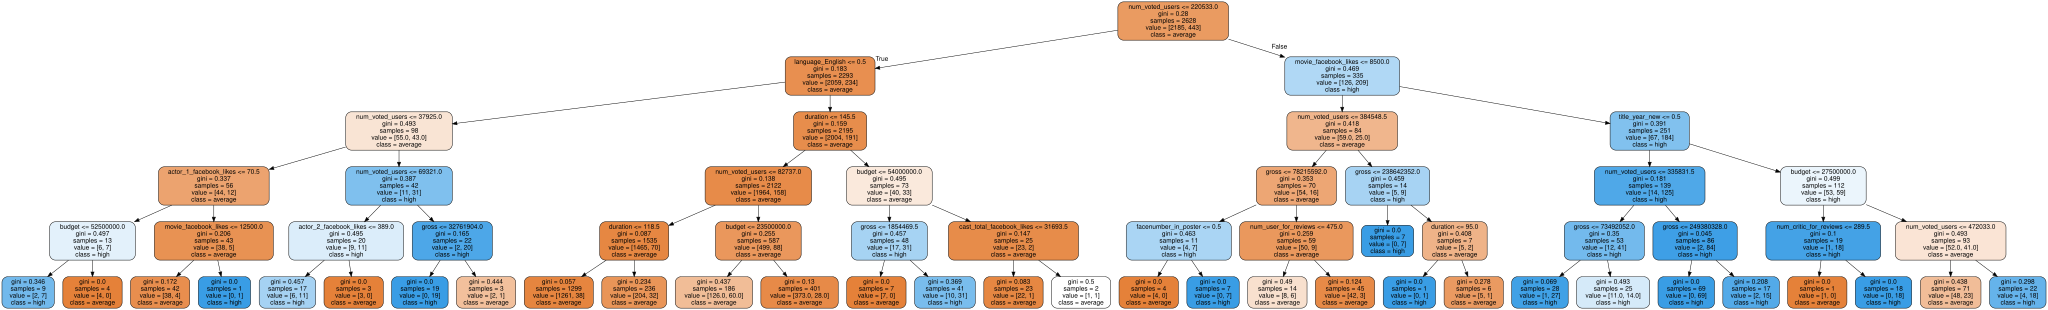

In [136]:
dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['average','high']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

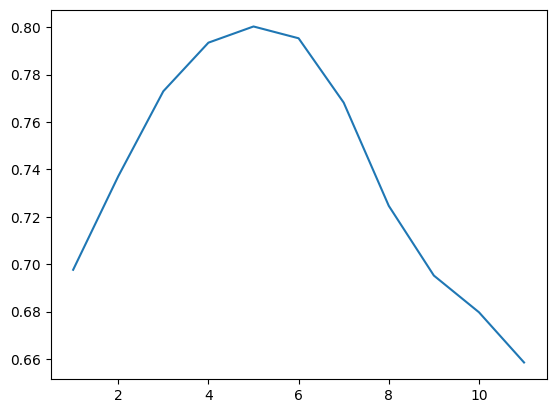

In [37]:
print(plt.plot(final_model.depth,final_model.auc)) #5 does in fact have the highest (best) AUC!

## 14 View the results, comment on how the model performed using several evaluation metrics. (ROC, F1)

## 15 Which variables appear to be contributing the most (variable importance) 

In [38]:
#Variable importance for the best estimator, how much weight does each feature have in determining the classification?
varimp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                              importance
num_user_for_reviews            0.419665
duration                        0.141181
budget                          0.124592
director_facebook_likes         0.063460
language_English                0.062786
gross                           0.049525
num_critic_for_reviews          0.026971
actor_1_facebook_likes          0.023128
actor_2_facebook_likes          0.022154
title_year_old                  0.021152
actor_1_name_Other              0.017436
imdb_score_low                  0.017213
actor_3_facebook_likes          0.010736
content_rating_R                0.000000
content_rating_PG-13            0.000000
language_Other                  0.000000
language_French                 0.000000
country_Other                   0.000000
color_Black and White           0.000000
content_rating_Other            0.000000
title_year_middle               0.000000
country_Big Country Producer    0.000000
actor_1_name_Famous             0.000000
title_year_new  

Number of users for reviews is the most important feature.

Axes(0.125,0.11;0.775x0.77)


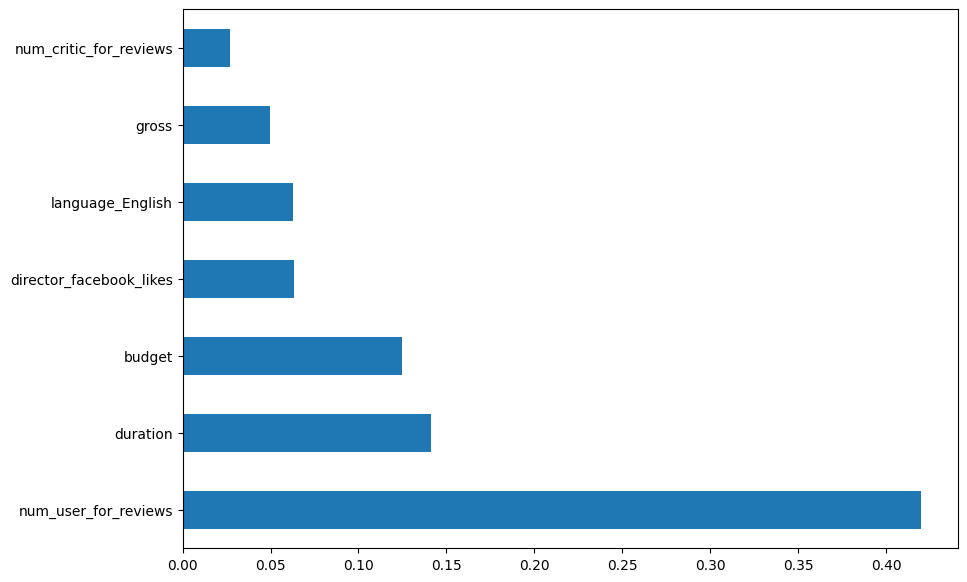

In [39]:
#Graph variable importance
plt.figure(figsize=(10,7))
print(varimp.importance.nlargest(7).plot(kind='barh')) #Alcohol has the largest impact by far!

#16 Use the predict method on the test data and print out the results.

## 17 How does the model perform on the test data?

In [40]:
print(best.score(X_test,y_test))

0.8457446808510638


## 18 Print out the confusion matrix for the test data, what does it tell you about the model?

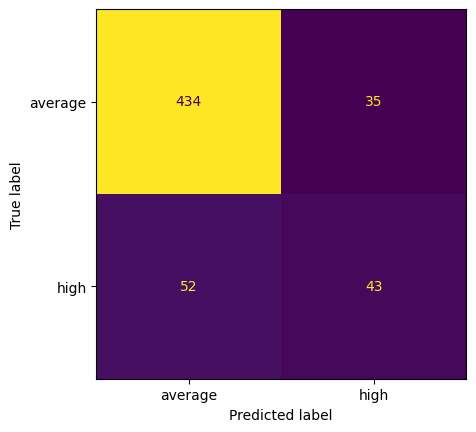

In [41]:
print(ConfusionMatrixDisplay.from_estimator(best,X_test,y_test, display_labels = ['average','high'], colorbar=False))

## 19 What are the top 3 movies based on the test set? Which variables are most important in predicting the top 3 movies?

In [42]:
# Predict probabilities
probs = clf.predict_proba(X_test)

# Get probability of being 'high' (label 1)
X_test_copy = X_test.copy()
X_test_copy['prob_high'] = probs[:, 1]

#re-access the movie_metadata data to acquire the movie titles
movie_title=pd.read_csv("../data/movie_metadata.csv")
X_test_copy=pd.concat([X_test_copy,movie_title['movie_title']],axis=1)

NameError: name 'clf' is not defined

In [ ]:
top_3 = X_test_copy.sort_values(by='prob_high', ascending=False).head(3)
print(top_3[['movie_title', 'prob_high']])

            movie_title  prob_high
66     The Dark Knight         1.0
233    How Do You Know         1.0
326  Gangs of New York         1.0


number of users for review is the most important factor.

## 20 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

Big thing.